In [71]:
import numpy as np
import base


In [67]:
def traveling_MC_constDist_break(points, dist_matrix, tries, starting_temp = 1, alpha = 0.999, ameloration = -0.01,
                                 tries_stop = 100, method =2):
    """ input:  points - points that should be visited by each path (in some order) - array
                dist_matrix - matrix containing the 'distances' between each point - 2darray
                tries - itterations of the Monte Carlos - Markov chain - int
                starting_temp - scalar in the exponent of the markov chain acception process - int
                alpha - scalar refgulating the decrease of the temperature after each loop iteration in the MC
                tries_stop - check for ameloration between d[x] and d[x+tries_stop] - int
                ameloration -  Improvement requiered to stop loop
                method - see Opt_method- cuurently random between Lin-2 & Lin-3
        return: points - points that should be visited by each path (in some order) - array
                pathWeights - 'distances' (better weights) of each path - array of int
                temps - temperatures after each MC step - array of int
    """
    
    pathWeights = np.zeros(tries+1)
    temps = np.zeros(tries+1)
    pathWeights[0] = totalTravelDist(points, dist_matrix)
    temps[0] = starting_temp
    cost = pathWeights[0]
    finish = False
    for i in range(tries):
        
        if finish == False:
            new_sequence = Opt_method(method,points)
            new_cost = totalTravelDist(new_sequence, dist_matrix)
            if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
                points = new_sequence
                cost = new_cost
            pathWeights[i+1] = cost
            temps[i+1] = alpha*temps[i] 
            if i > tries_stop:
                counter = 0
                for z in range(tries_stop):
                    if -10**(-9) < pathWeights[i+1-z]/pathWeights[i+1]-1 < ameloration:
                        counter = counter +1
                if counter == tries_stop:
                    print('requirement met at ',i,'try')
                    finish = True
        else:
            pathWeights[i+1] = cost
            temps[i+1] = temps[i]
                
    return(points, pathWeights, temps)

In [8]:
import matrix
import matplotlib.pyplot as plt

In [62]:
D,x,y = matrix.random_dist_matrix(40,0,4) # neu in matrix.py

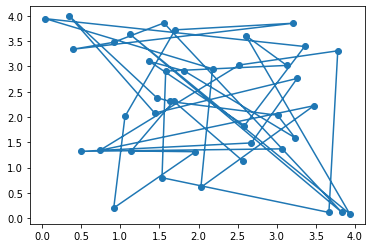

In [63]:
plt.plot(x,y)
plt.scatter(x,y)

In [68]:
t = np.arange(40)
stepse = np.arange(10001)

# Testreihe fürs Abbruchkriterium

Mindestens $\text{tries_stop}$ lang soll $\frac{x_\text{alt}}{x_\text{neu}}-1 < \text{ameloration}$ sein. Die Testreihe läuft für $ameloration =[0.1,0.01,0.001]$ für verschieden Protzente von  $\text{tries_stop}$.

requirement met at  2 try
requirement met at  481 try
requirement met at  1903 try
requirement met at  3898 try
requirement met at  4262 try
requirement met at  8347 try


C:\Users\Win10\Computational physics\Projects\base.py:220: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


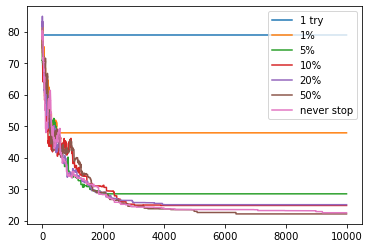

In [72]:
# mind10% Verbesserung gewünscht

tries = 10000
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=1,ameloration=0.1)[1],label='1 try')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=int(0.01*tries),ameloration=0.1)[1],label='1%')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=int(0.05*tries),ameloration=0.1)[1],label='5%')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=int(0.1*tries),ameloration=0.1)[1],label='10%')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=int(0.2*tries),ameloration=0.1)[1],label='20%')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=int(0.5*tries),ameloration=0.1)[1],label='50%')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,ameloration= -0.01)[1],label='never stop')
plt.legend()

stop at  2 try-> requirements met
stop at  57 try-> requirements met
stop at  480 try-> requirements met
stop at  1404 try-> requirements met
stop at  2624 try-> requirements met
stop at  4919 try-> requirements met


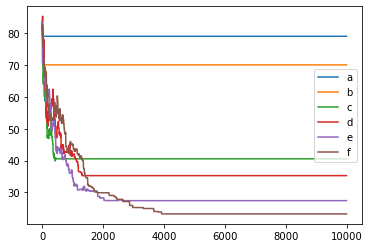

In [57]:
# 
tries = 10000
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=1,ameloration=0.01)[1],label='1 try')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=int(0.01*tries),ameloration=0.01)[1],label='1%')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=int(0.05*tries),ameloration=0.01)[1],label='5%')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=int(0.1*tries),ameloration=0.01)[1],label='10%')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=int(0.2*tries),ameloration=0.01)[1],label='20%')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=int(0.5*tries),ameloration=0.01)[1],label='50%')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,ameloration= -0.01)[1],label='never stop')
plt.legend()

requirement met at  2 try
requirement met at  1859 try
requirement met at  4260 try
requirement met at  8231 try


C:\Users\Win10\AppData\Local\Temp/ipykernel_5208/1662429992.py:27: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
C:\Users\Win10\AppData\Local\Temp/ipykernel_5208/1662429992.py:27: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


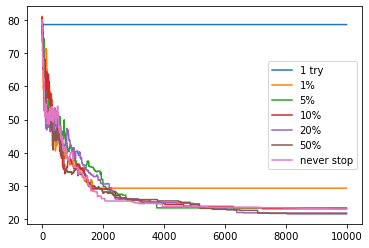

In [70]:
tries = 10000
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=1,ameloration=0.001)[1],label='1 try')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=int(0.01*tries),ameloration=0.001)[1],label='1%')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=int(0.05*tries),ameloration=0.001)[1],label='5%')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=int(0.1*tries),ameloration=0.001)[1],label='10%')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=int(0.2*tries),ameloration=0.001)[1],label='20%')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,tries_stop=int(0.5*tries),ameloration=0.001)[1],label='50%')
plt.plot(stepse,base.traveling_MC_constDist_break(t,D,tries,ameloration= -0.01)[1],label='never stop')
plt.legend()

Von den Tests her würde ich ameloration=0.001 (unterschied zwischen x_neu und x_alt beträgt weniger als 0,1% von x_neu) vorschlagen mit tries_stop zwischen 10-25% von tries.